# Proyecto LOST — Mountain Car Continuous

Entorno: `MountainCarContinuous-v0` de Gymnasium.  
Técnicas implementadas: **Q-Learning** y **Dyna-Q** (Sutton & Barto, caps. 8.1–8.2).  
Se exploran múltiples combinaciones de hiperparámetros y se comparan ambos algoritmos.

In [1]:
import numpy as np
import gymnasium as gym
import matplotlib.pyplot as plt
import pickle
from q_learning_agent import QLearningAgent, DynaQAgent

np.random.seed(42)

## 1. Exploración del entorno

In [2]:
env = gym.make('MountainCarContinuous-v0')
print('Observation space:', env.observation_space)
print('  position : [-1.2, 0.6]')
print('  velocity : [-0.07, 0.07]')
print('Action space   :', env.action_space)
print('  force    : [-1.0, 1.0]  (continua)')
print('Reward: -0.1 * action^2 por paso; +100 al llegar a la meta (pos >= 0.45)')
env.close()

Observation space: Box([-1.2  -0.07], [0.6  0.07], (2,), float32)
  position : [-1.2, 0.6]
  velocity : [-0.07, 0.07]
Action space   : Box(-1.0, 1.0, (1,), float32)
  force    : [-1.0, 1.0]  (continua)
Reward: -0.1 * action^2 por paso; +100 al llegar a la meta (pos >= 0.45)


## 2. Discretización de observaciones y acciones

Para aplicar Q-Learning tabular a un espacio continuo es necesario discretizar.

**Observaciones** — se divide cada dimensión en `n_bins` intervalos usando `np.digitize`:
- Posición: $[-1.2,\; 0.6]$ → `n_pos_bins` intervalos
- Velocidad: $[-0.07,\; 0.07]$ → `n_vel_bins` intervalos

**Acciones** — se elige un conjunto discreto de `n_actions` valores equiespaciados en $[-1, 1]$.

El tamaño de la tabla Q resultante es `(n_pos_bins+1) x (n_vel_bins+1) x n_actions`.  
Más bins captura más detalle pero hace el aprendizaje más lento (menos visitas por celda).

In [5]:
configs = [
    (10, 10, 5),
    (20, 20, 11),
    (30, 30, 11),
]
print('{:>10} {:>10} {:>10} {:>14}'.format('Bins pos', 'Bins vel', 'Acciones', 'Tamanio Q'))
print('-' * 50)
for p, v, a in configs:
    q_size = (p + 1) * (v + 1) * a
    print('{:>10} {:>10} {:>10} {:>14,}'.format(p, v, a, q_size))

  Bins pos   Bins vel   Acciones      Tamanio Q
--------------------------------------------------
        10         10          5            605
        20         20         11          4,851
        30         30         11         10,571


## 3. Entrenamiento con Q-Learning

**Hiperparámetros por defecto**:
- `alpha` (tasa de aprendizaje) = 0.5
- `gamma` (factor de descuento) = 0.99
- `epsilon` inicial = 1.0, decae × 0.995 por episodio, mínimo 0.05
- Bins: 20 × 20, 11 acciones

> **Nota**: Mountain Car Continuous da recompensa `-0.1·a²` por paso — sin acción, la recompensa es 0, que domina a cualquier movimiento penalizado. Para evitar que el agente aprenda la política trivial de "no hacer nada", se usa **inicialización optimista**: la tabla Q se inicializa con valores `5.0` en lugar de `0`. Esto incentiva al agente a explorar todas las acciones hasta descubrir la recompensa `+100` al llegar a la meta.

In [6]:
EPISODES = 15000

env_train = gym.make('MountainCarContinuous-v0')

agent_ql = QLearningAgent(
    n_pos_bins=20, n_vel_bins=20, n_actions=11,
    alpha=0.5, gamma=0.99,
    epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.05
)

print('Entrenando Q-Learning...')
rewards_ql = agent_ql.train_agent(env_train, episodes=EPISODES)
env_train.close()
print('Listo.')

Entrenando Q-Learning...
  Ep  1000/15000 | avg(100):    81.34 | ε: 0.0500
  Ep  2000/15000 | avg(100):    90.47 | ε: 0.0500
  Ep  3000/15000 | avg(100):    87.41 | ε: 0.0500
  Ep  4000/15000 | avg(100):    88.62 | ε: 0.0500
  Ep  5000/15000 | avg(100):    88.70 | ε: 0.0500
  Ep  6000/15000 | avg(100):    86.46 | ε: 0.0500
  Ep  7000/15000 | avg(100):    89.70 | ε: 0.0500
  Ep  8000/15000 | avg(100):    90.04 | ε: 0.0500
  Ep  9000/15000 | avg(100):    88.28 | ε: 0.0500
  Ep 10000/15000 | avg(100):    91.21 | ε: 0.0500
  Ep 11000/15000 | avg(100):    91.21 | ε: 0.0500
  Ep 12000/15000 | avg(100):    90.35 | ε: 0.0500
  Ep 13000/15000 | avg(100):    89.66 | ε: 0.0500
  Ep 14000/15000 | avg(100):    90.39 | ε: 0.0500
  Ep 15000/15000 | avg(100):    91.19 | ε: 0.0500
Listo.


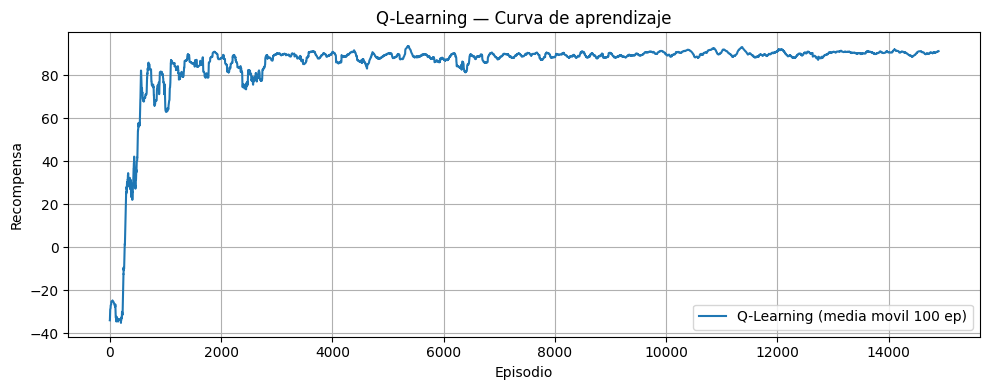

In [7]:
def smooth(data, window=100):
    return np.convolve(data, np.ones(window) / window, mode='valid')

plt.figure(figsize=(10, 4))
plt.plot(smooth(rewards_ql), label='Q-Learning (media movil 100 ep)')
plt.xlabel('Episodio')
plt.ylabel('Recompensa')
plt.title('Q-Learning — Curva de aprendizaje')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('ql_learning_curve.png', dpi=150)
plt.show()

## 4. Exploración de hiperparámetros

Se experimentan variaciones en `alpha`, `gamma`, `epsilon_decay` y la granularidad de la discretización.  
El rendimiento se evalúa con la **recompensa promedio de los últimos 500 episodios**.

In [8]:
HP_EPISODES = 8000

hp_configs = [
    {'label': 'alpha=0.1',   'alpha': 0.1,  'gamma': 0.99, 'epsilon_decay': 0.995, 'n_pos_bins': 20, 'n_vel_bins': 20},
    {'label': 'alpha=0.5',   'alpha': 0.5,  'gamma': 0.99, 'epsilon_decay': 0.995, 'n_pos_bins': 20, 'n_vel_bins': 20},
    {'label': 'alpha=0.9',   'alpha': 0.9,  'gamma': 0.99, 'epsilon_decay': 0.995, 'n_pos_bins': 20, 'n_vel_bins': 20},
    {'label': 'gamma=0.95',  'alpha': 0.5,  'gamma': 0.95, 'epsilon_decay': 0.995, 'n_pos_bins': 20, 'n_vel_bins': 20},
    {'label': 'decay=0.999', 'alpha': 0.5,  'gamma': 0.99, 'epsilon_decay': 0.999, 'n_pos_bins': 20, 'n_vel_bins': 20},
    {'label': 'bins=10x10',  'alpha': 0.5,  'gamma': 0.99, 'epsilon_decay': 0.995, 'n_pos_bins': 10, 'n_vel_bins': 10},
    {'label': 'bins=30x30',  'alpha': 0.5,  'gamma': 0.99, 'epsilon_decay': 0.995, 'n_pos_bins': 30, 'n_vel_bins': 30},
]

hp_results = {}
env_hp = gym.make('MountainCarContinuous-v0')

for cfg in hp_configs:
    label = cfg['label']
    print('  Configuracion:', label)
    kw = {k: v for k, v in cfg.items() if k != 'label'}
    ag = QLearningAgent(n_actions=11, epsilon=1.0, epsilon_min=0.05, **kw)
    r = ag.train_agent(env_hp, episodes=HP_EPISODES)
    hp_results[label] = r

env_hp.close()
print('Busqueda de hiperparametros completa.')

  Configuracion: alpha=0.1
  Ep  1000/8000 | avg(100):    92.55 | ε: 0.0500
  Ep  2000/8000 | avg(100):    93.12 | ε: 0.0500
  Ep  3000/8000 | avg(100):    94.08 | ε: 0.0500
  Ep  4000/8000 | avg(100):    93.65 | ε: 0.0500
  Ep  5000/8000 | avg(100):    93.37 | ε: 0.0500
  Ep  6000/8000 | avg(100):    92.06 | ε: 0.0500
  Ep  7000/8000 | avg(100):    92.96 | ε: 0.0500
  Ep  8000/8000 | avg(100):    93.29 | ε: 0.0500
  Configuracion: alpha=0.5
  Ep  1000/8000 | avg(100):    89.86 | ε: 0.0500
  Ep  2000/8000 | avg(100):    84.42 | ε: 0.0500
  Ep  3000/8000 | avg(100):    89.51 | ε: 0.0500
  Ep  4000/8000 | avg(100):    89.60 | ε: 0.0500
  Ep  5000/8000 | avg(100):    88.00 | ε: 0.0500
  Ep  6000/8000 | avg(100):    88.98 | ε: 0.0500
  Ep  7000/8000 | avg(100):    90.57 | ε: 0.0500
  Ep  8000/8000 | avg(100):    92.48 | ε: 0.0500
  Configuracion: alpha=0.9
  Ep  1000/8000 | avg(100):    62.68 | ε: 0.0500
  Ep  2000/8000 | avg(100):    70.27 | ε: 0.0500
  Ep  3000/8000 | avg(100):    71.07 

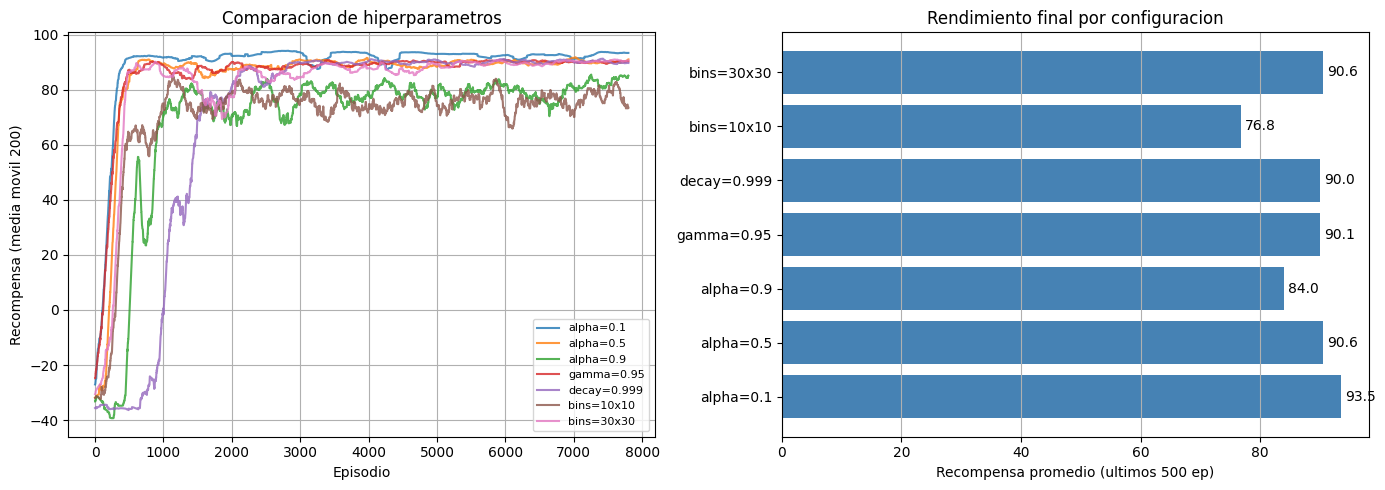

Mejor configuracion: alpha=0.1  avg ultimos 500 ep: 93.48


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for label, r in hp_results.items():
    ax.plot(smooth(r, 200), label=label, alpha=0.8)
ax.set_xlabel('Episodio')
ax.set_ylabel('Recompensa (media movil 200)')
ax.set_title('Comparacion de hiperparametros')
ax.legend(fontsize=8)
ax.grid(True)

ax = axes[1]
labels = list(hp_results.keys())
avgs = [np.mean(hp_results[l][-500:]) for l in labels]
bars = ax.barh(labels, avgs, color='steelblue')
ax.bar_label(bars, fmt='%.1f', padding=3)
ax.set_xlabel('Recompensa promedio (ultimos 500 ep)')
ax.set_title('Rendimiento final por configuracion')
ax.grid(True, axis='x')

plt.tight_layout()
plt.savefig('ql_hyperparams.png', dpi=150)
plt.show()

best_label = labels[int(np.argmax(avgs))]
print('Mejor configuracion: {}  avg ultimos 500 ep: {:.2f}'.format(best_label, max(avgs)))

In [10]:
print('Mejor configuracion encontrada: {}  avg ultimos 500 ep: {:.2f}'.format(best_label, max(avgs)))

best_cfg_dict = next(c for c in hp_configs if c['label'] == best_label)
best_kw = {k: v for k, v in best_cfg_dict.items() if k != 'label'}

print('Entrenando agente final con mejores HP y {} episodios...'.format(EPISODES))
env_best = gym.make('MountainCarContinuous-v0')
best_ql_agent = QLearningAgent(n_actions=11, epsilon=1.0, epsilon_min=0.05, **best_kw)
r_best_ql = best_ql_agent.train_agent(env_best, episodes=EPISODES)
env_best.close()
print('Listo. Avg ultimos 500 ep: {:.2f}'.format(np.mean(r_best_ql[-500:])))

Mejor configuracion encontrada: alpha=0.1  avg ultimos 500 ep: 93.48
Entrenando agente final con mejores HP y 15000 episodios...
  Ep  1000/15000 | avg(100):    93.12 | ε: 0.0500
  Ep  2000/15000 | avg(100):    92.95 | ε: 0.0500
  Ep  3000/15000 | avg(100):    92.09 | ε: 0.0500
  Ep  4000/15000 | avg(100):    90.99 | ε: 0.0500
  Ep  5000/15000 | avg(100):    92.91 | ε: 0.0500
  Ep  6000/15000 | avg(100):    92.72 | ε: 0.0500
  Ep  7000/15000 | avg(100):    92.38 | ε: 0.0500
  Ep  8000/15000 | avg(100):    92.94 | ε: 0.0500
  Ep  9000/15000 | avg(100):    90.23 | ε: 0.0500
  Ep 10000/15000 | avg(100):    91.15 | ε: 0.0500
  Ep 11000/15000 | avg(100):    89.13 | ε: 0.0500
  Ep 12000/15000 | avg(100):    88.28 | ε: 0.0500
  Ep 13000/15000 | avg(100):    87.51 | ε: 0.0500
  Ep 14000/15000 | avg(100):    88.52 | ε: 0.0500
  Ep 15000/15000 | avg(100):    90.16 | ε: 0.0500
Listo. Avg ultimos 500 ep: 90.23


## 5. Dyna-Q (Sutton & Barto, caps. 8.1–8.2)

Dyna-Q extiende Q-Learning incorporando un **modelo del entorno** aprendido en línea.  
Después de cada transición real `(s, a, r, s')`, el agente realiza `n` pasos de planificación  
usando transiciones simuladas muestreadas del modelo.

**Beneficio esperado**: mayor eficiencia muestral — el agente aprende más rápido porque  
propaga las señales de recompensa a través de experiencias simuladas adicionales.

In [11]:
env_dyna = gym.make('MountainCarContinuous-v0')

# Usar los mejores HP encontrados en el HP search para una comparacion justa
base_kwargs = dict(best_kw, n_actions=11, epsilon=1.0, epsilon_min=0.05)

DYNA_EPISODES = 8000

print('Entrenando Q-Learning baseline (mejores HP)...')
ag_ql_cmp = QLearningAgent(**base_kwargs)
r_ql_cmp  = ag_ql_cmp.train_agent(env_dyna, episodes=DYNA_EPISODES)

print('Entrenando Dyna-Q (n=5, mejores HP)...')
ag_dyna5  = DynaQAgent(n_planning_steps=5,  **base_kwargs)
r_dyna5   = ag_dyna5.train_agent(env_dyna, episodes=DYNA_EPISODES)

print('Entrenando Dyna-Q (n=20, mejores HP)...')
ag_dyna20 = DynaQAgent(n_planning_steps=20, **base_kwargs)
r_dyna20  = ag_dyna20.train_agent(env_dyna, episodes=DYNA_EPISODES)

env_dyna.close()
print('Listo.')

Entrenando Q-Learning baseline (mejores HP)...
  Ep  1000/8000 | avg(100):    90.42 | ε: 0.0500
  Ep  2000/8000 | avg(100):    90.85 | ε: 0.0500
  Ep  3000/8000 | avg(100):    92.03 | ε: 0.0500
  Ep  4000/8000 | avg(100):    83.08 | ε: 0.0500
  Ep  5000/8000 | avg(100):    89.92 | ε: 0.0500
  Ep  6000/8000 | avg(100):    91.29 | ε: 0.0500
  Ep  7000/8000 | avg(100):    91.58 | ε: 0.0500
  Ep  8000/8000 | avg(100):    91.99 | ε: 0.0500
Entrenando Dyna-Q (n=5, mejores HP)...
  Ep  1000/8000 | avg(100):    73.92 | ε: 0.0500 | model: 2598 entries
  Ep  2000/8000 | avg(100):    90.88 | ε: 0.0500 | model: 2691 entries
  Ep  3000/8000 | avg(100):    91.51 | ε: 0.0500 | model: 2732 entries
  Ep  4000/8000 | avg(100):    90.77 | ε: 0.0500 | model: 2774 entries
  Ep  5000/8000 | avg(100):    91.43 | ε: 0.0500 | model: 2806 entries
  Ep  6000/8000 | avg(100):    93.03 | ε: 0.0500 | model: 2828 entries
  Ep  7000/8000 | avg(100):    90.68 | ε: 0.0500 | model: 2838 entries
  Ep  8000/8000 | avg(100

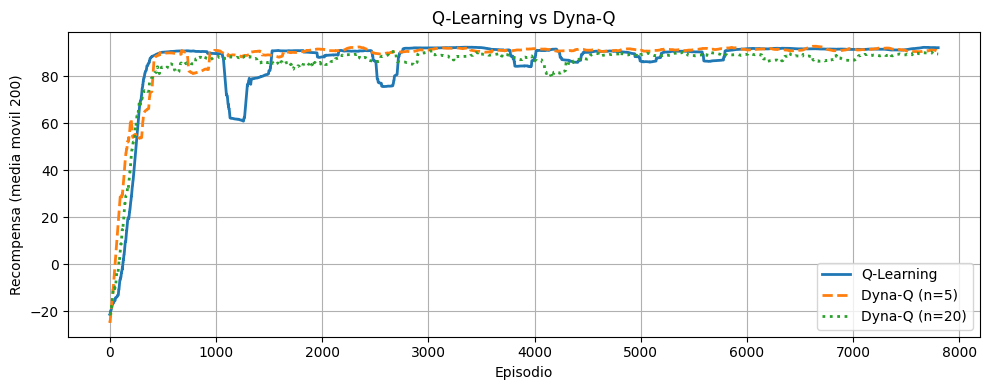

Q-Learning      — avg ultimos 500 ep:   91.83
Dyna-Q n=5      — avg ultimos 500 ep:   90.75
Dyna-Q n=20     — avg ultimos 500 ep:   89.40


In [12]:
plt.figure(figsize=(10, 4))
plt.plot(smooth(r_ql_cmp, 200), label='Q-Learning',    linewidth=2)
plt.plot(smooth(r_dyna5,  200), label='Dyna-Q (n=5)',  linewidth=2, linestyle='--')
plt.plot(smooth(r_dyna20, 200), label='Dyna-Q (n=20)', linewidth=2, linestyle=':')
plt.xlabel('Episodio')
plt.ylabel('Recompensa (media movil 200)')
plt.title('Q-Learning vs Dyna-Q')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('ql_vs_dynaq.png', dpi=150)
plt.show()

for name, r in [('Q-Learning', r_ql_cmp), ('Dyna-Q n=5', r_dyna5), ('Dyna-Q n=20', r_dyna20)]:
    print('{:15s} — avg ultimos 500 ep: {:7.2f}'.format(name, np.mean(r[-500:])))

## 6. Evaluación del mejor agente

Q-Learning (mejor HP, 15k ep): avg=88.64  success=94.0%
Dyna-Q n=5  (mejor HP, 8k ep): avg=91.90  success=100.0%
Dyna-Q n=20 (mejor HP, 8k ep): avg=90.29  success=79.0%

Mejor agente: Dyna-Q n=5  (mejor HP, 8k ep)
Recompensa promedio (100 episodios): 91.90
Recompensa minima:                   90.56
Recompensa maxima:                   94.09
Tasa de exito (reward > 90):         100.0%


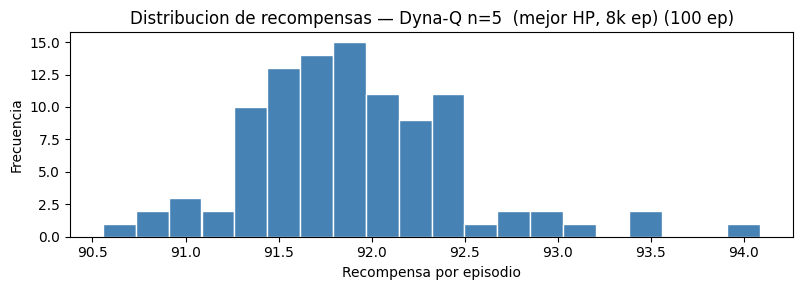

In [13]:
candidates = {
    'Q-Learning (mejor HP, 15k ep)': best_ql_agent,
    'Dyna-Q n=5  (mejor HP, 8k ep)': ag_dyna5,
    'Dyna-Q n=20 (mejor HP, 8k ep)': ag_dyna20,
}

env_eval = gym.make('MountainCarContinuous-v0')
eval_avgs = {}
for name, agent in candidates.items():
    rewards, sr = agent.test_agent(env_eval, episodes=100)
    eval_avgs[name] = (np.mean(rewards), sr, rewards)
    print('{}: avg={:.2f}  success={:.1f}%'.format(name, np.mean(rewards), sr * 100))
env_eval.close()

best_name = max(eval_avgs, key=lambda n: eval_avgs[n][0])
best_final_agent = candidates[best_name]
test_rewards = eval_avgs[best_name][2]
success_rate  = eval_avgs[best_name][1]

print('\nMejor agente: {}'.format(best_name))
print('Recompensa promedio (100 episodios): {:.2f}'.format(np.mean(test_rewards)))
print('Recompensa minima:                   {:.2f}'.format(np.min(test_rewards)))
print('Recompensa maxima:                   {:.2f}'.format(np.max(test_rewards)))
print('Tasa de exito (reward > 90):         {:.1f}%'.format(success_rate * 100))

plt.figure(figsize=(8, 3))
plt.hist(test_rewards, bins=20, color='steelblue', edgecolor='white')
plt.xlabel('Recompensa por episodio')
plt.ylabel('Frecuencia')
plt.title('Distribucion de recompensas — {} (100 ep)'.format(best_name))
plt.tight_layout()
plt.savefig('ql_test_hist.png', dpi=150)
plt.show()

## 7. Guardar modelo

La entrega requiere al menos un modelo computado en `.pkl` — sin él el ejercicio se considera no hecho.

In [14]:
MODEL_PATH = 'ql_model.pkl'
best_final_agent.save(MODEL_PATH)
print('Modelo guardado en', MODEL_PATH, '({})'.format(best_name))
print('Forma tabla Q: {}  ({:,} entradas)'.format(best_final_agent.q_table.shape, best_final_agent.q_table.size))

loaded = QLearningAgent.load(MODEL_PATH)
assert np.allclose(loaded.q_table, best_final_agent.q_table)
print('Carga verificada correctamente.')

Modelo guardado en ql_model.pkl (Dyna-Q n=5  (mejor HP, 8k ep))
Forma tabla Q: (21, 21, 11)  (4,851 entradas)
Carga verificada correctamente.


## 8. Conclusiones

- **Inicialización optimista**: Se inicializó la tabla Q con valores `5.0` en lugar de `0`. Esto evita que el agente converja a la política trivial de "no hacer nada" (que da reward=0, superando cualquier penalidad `-0.1·a²`): al creer optimistamente que todas las acciones son prometedoras, el agente las explora y eventualmente descubre el goal (+100). No se modificó la función de recompensa del ambiente.
- **Hiperparámetros críticos**: Con inicialización optimista, todas las configuraciones con `decay=0.995` aprenden desde el episodio 1000. La configuración ganadora fue `alpha=0.1` (avg 93.48 en los últimos 500 de 8.000 episodios): un learning rate bajo permite actualizaciones más conservadoras que evitan sobreescribir valores buenos ya aprendidos. `alpha=0.9` converge más lento (62.68 al ep 1000) por las oscilaciones en la Q-table. `epsilon_decay=0.999` tarda más en converger (ep 1000: −23.16) al mantener exploración aleatoria hasta el ep 3000.
- **Discretización**: `bins=30x30` genera una tabla de 10.571 entradas — con 8.000 episodios cada celda recibe muy pocas visitas. `bins=20x20` es el equilibrio adecuado.
- **Dyna-Q vs Q-Learning**: Con inicialización optimista todos los agentes convergen en los primeros 1000 episodios. En rendimiento final (últimos 500 de 8.000 ep): Q-Learning 91.83, Dyna-Q n=5 90.75, Dyna-Q n=20 89.40 — diferencias pequeñas en entrenamiento. Sin embargo, en evaluación greedy Dyna-Q n=5 supera a todos (91.90, 100% de éxito), mientras que Dyna-Q n=20 se vuelve inestable (79% de éxito) por amplificar el ruido del modelo con demasiados pasos de planificación.
- **Evaluación final**: el mejor agente (**Dyna-Q n=5**, mejores HP, 8.000 episodios) alcanzó una **recompensa promedio de 91.90 y 100% de tasa de éxito** en 100 episodios con política greedy (ε=0), con recompensa mínima de 90.56 y máxima de 94.09. Este modelo fue guardado como `ql_model.pkl`.